In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt


pd.options.display.max_columns = 999
pd.options.display.float_format = "{:.2f}".format

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

dataset1 = data_path = "/content/drive/MyDrive/BOOTACAMP'S FILE/superstore_dataset - segmentation - superstore (1).csv"

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## Data Understanding

In [ ]:
df= pd.read_csv(dataset1)
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,subcategory,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   object 
 2   order_date     9994 non-null   object 
 3   ship_date      9994 non-null   object 
 4   ship_mode      9994 non-null   object 
 5   customer_id    9994 non-null   object 
 6   customer_name  9994 non-null   object 
 7   segment        9994 non-null   object 
 8   country        9994 non-null   object 
 9   city           9994 non-null   object 
 10  state          9994 non-null   object 
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   object 
 13  product_id     9994 non-null   object 
 14  category       9994 non-null   object 
 15  subcategory    9994 non-null   object 
 16  product_name   9994 non-null   object 
 17  sales          9994 non-null   float64
 18  quantity

In [ ]:
df['order_date']=pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [ ]:
df.describe()

,row_id,order_date,ship_date,postal_code,sales,quantity,discount,profit
count,9994.00,9994,9994,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,2016-04-30 00:07:12.259355392,2016-05-03 23:06:58.571142912,55190.38,229.86,3.79,0.16,28.66
min,1.00,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.00,209.94,5.00,0.20,29.36
max,9994.00,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.00,22638.48,14.00,0.80,8399.98
std,2885.16,NaN,NaN,32063.69,623.25,2.23,0.21,234.26


In [ ]:
df.isnull().sum()

,0
row_id,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_id,0
customer_name,0
segment,0
country,0
city,0


In [ ]:
print("Duplikat:", df.duplicated().sum())

print("Shape:", df.shape)

Duplikat: 0
Shape: (9994, 21)


In [ ]:
print("Jumlah customer unik :", df['customer_id'].nunique())
print("Jumlah order unik    :", df['order_id'].nunique())
print("Jumlah produk unik   :", df['product_id'].nunique())
print("Rentang tanggal      :", df['order_date'].min(), "-", df['order_date'].max())

Jumlah customer unik : 793
Jumlah order unik    : 5009
Jumlah produk unik   : 1862
Rentang tanggal      : 2014-01-03 00:00:00 - 2017-12-30 00:00:00


In [ ]:
region_check = df.groupby('customer_id')['region'].nunique()
print("Customer dengan region lebih dari 1:", (region_check > 1).sum(), "dari", df['customer_id'].nunique())

segment_check = df.groupby('customer_id')['segment'].nunique()
print("Customer dengan segment lebih dari 1:", (segment_check > 1).sum())

Customer dengan region lebih dari 1: 766 dari 793
Customer dengan segment lebih dari 1: 0


## EDA

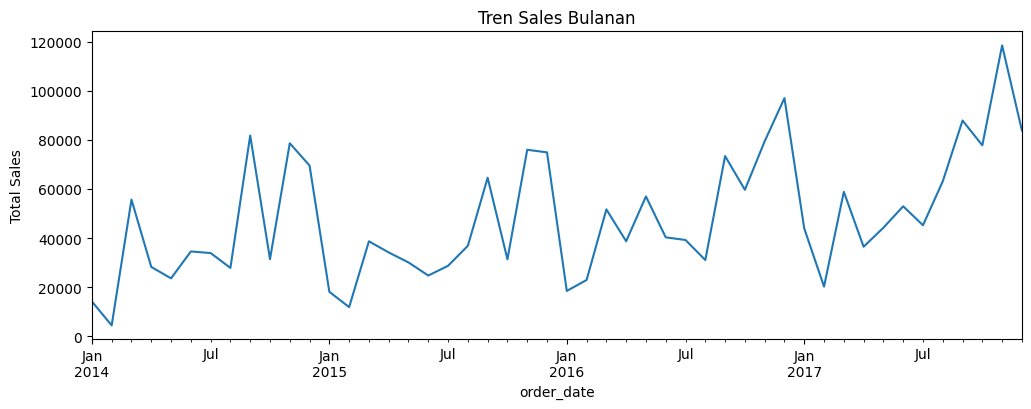

In [ ]:
# Tren sales bulanan
monthly_sales = df.set_index('order_date').resample('ME')['sales'].sum()
monthly_sales.plot(figsize=(12,4), title='Tren Sales Bulanan')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df['Tahun'] = monthly_sales_df['order_date'].dt.year
monthly_sales_df['Bulan'] = monthly_sales_df['order_date'].dt.month_name()

# 2 Bulan dengan penjualan TERTINGGI (Puncak) di setiap tahun
idx_max = monthly_sales_df.groupby('Tahun')['sales'].idxmax()
puncak_tahunan = monthly_sales_df.loc[idx_max, ['Tahun', 'Bulan', 'sales']]

print("=== BULAN PUNCAK PENJUALAN TAHUNAN ===")
print(puncak_tahunan.to_string(index=False))

# Bulan dengan penjualan TERENDAH (Lembah) di setiap tahun
idx_min = monthly_sales_df.groupby('Tahun')['sales'].idxmin()
lembah_tahunan = monthly_sales_df.loc[idx_min, ['Tahun', 'Bulan', 'sales']]

print("\n=== BULAN PENJUALAN TERENDAH TAHUNAN ===")
print(lembah_tahunan.to_string(index=False))

=== BULAN PUNCAK PENJUALAN TAHUNAN ===
 Tahun     Bulan     sales
  2014 September  81777.35
  2015  November  75972.56
  2016  December  96999.04
  2017  November 118447.82

=== BULAN PENJUALAN TERENDAH TAHUNAN ===
 Tahun    Bulan    sales
  2014 February  4519.89
  2015 February 11951.41
  2016  January 18542.49
  2017 February 20301.13


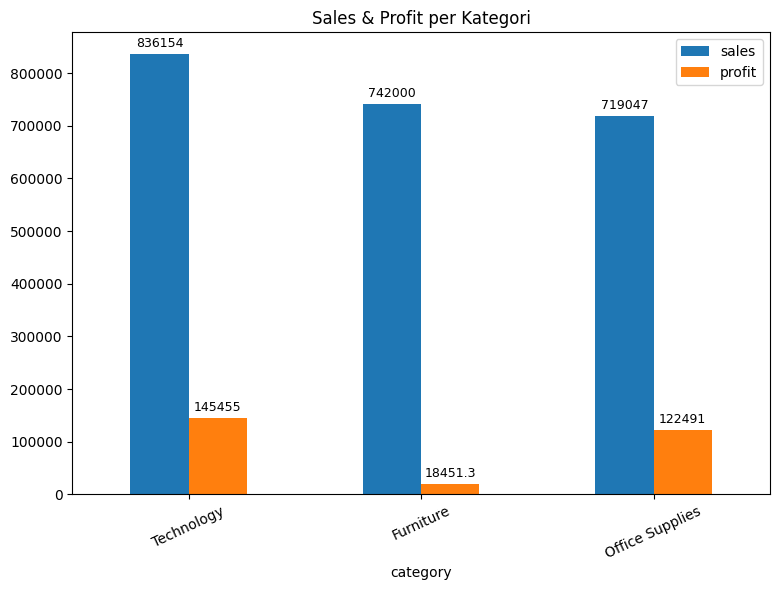

In [ ]:
# Sales & profit per kategori
cat_summary = df.groupby('category')[['sales','profit']].sum().sort_values('sales', ascending=False)
ax= cat_summary.plot(kind='bar', figsize=(9,6), title='Sales & Profit per Kategori')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
plt.xticks(rotation=25)

plt.show()

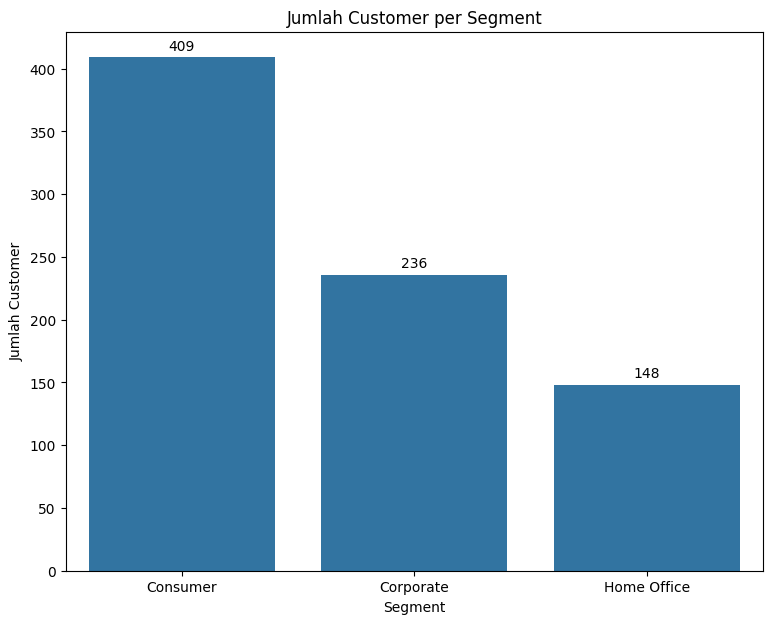

In [ ]:
# Distribusi customer per segment

plt.figure(figsize=(9,7))
ax =sns.countplot(data=df.drop_duplicates('customer_id'), x='segment')
ax.bar_label(ax.containers[0], padding=3, fontsize=10)


plt.title('Jumlah Customer per Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Jumlah Customer')
plt.show()

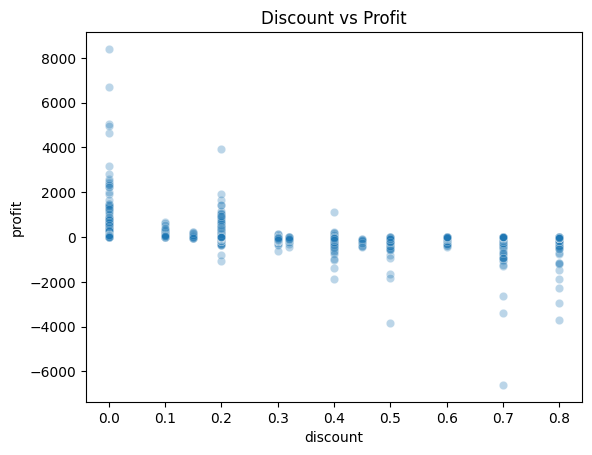

In [ ]:
# Korelasi discount vs profit
sns.scatterplot(data=df, x='discount', y='profit', alpha=0.3)
plt.title('Discount vs Profit')
plt.show()

In [ ]:
df.head(5)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,subcategory,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [ ]:
# Agregasi ke Level Order lalu Customer

order_level = df.groupby(
    ['order_id','customer_id','customer_name','segment','region','order_date']
).agg(
    order_sales=('sales','sum'),
    order_profit=('profit','sum'),
    order_qty=('quantity','sum')
).reset_index()

region_mode = order_level.groupby('customer_id')['region'] \
    .agg(lambda x: x.mode().iloc[0]).rename('most_common_region')

snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

customer_level = order_level.groupby(['customer_id','customer_name','segment']).agg(
    last_purchase=('order_date','max'),
    first_purchase=('order_date','min'),
    frequency=('order_id','nunique'),
    monetary=('order_sales','sum'),
    total_profit=('order_profit','sum')
).reset_index()

customer_level = customer_level.merge(region_mode, on='customer_id')
customer_level['recency_days'] = (snapshot_date - customer_level['last_purchase']).dt.days
customer_level['tenure_days'] = (customer_level['last_purchase'] - customer_level['first_purchase']).dt.days
customer_level['avg_order_value'] = customer_level['monetary'] / customer_level['frequency']

customer_level.head()

,customer_id,customer_name,segment,last_purchase,first_purchase,frequency,monetary,total_profit,most_common_region,recency_days,tenure_days,avg_order_value
0,AA-10315,Alex Avila,Consumer,2017-06-29,2014-03-31,5,5563.56,-362.88,Central,185,1186,1112.71
1,AA-10375,Allen Armold,Consumer,2017-12-11,2014-04-21,9,1056.39,277.38,West,20,1330,117.38
2,AA-10480,Andrew Allen,Consumer,2017-04-15,2014-05-04,4,1790.51,435.83,Central,260,1077,447.63
3,AA-10645,Anna Andreadi,Consumer,2017-11-05,2014-06-22,6,5086.93,857.80,East,56,1232,847.82
4,AB-10015,Aaron Bergman,Consumer,2016-11-10,2014-02-18,3,886.16,129.35,Central,416,996,295.39


In [ ]:
# RFM Scoring

# --- Ubah scoring RFM ke skala 1-5 (quintile) ---
customer_level['R_score'] = pd.qcut(customer_level['recency_days'], 5, labels=[5,4,3,2,1]).astype(int)
customer_level['F_score'] = pd.qcut(customer_level['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
customer_level['M_score'] = pd.qcut(customer_level['monetary'], 5, labels=[1,2,3,4,5]).astype(int)

# --- Mapping ke 7 Segmen berdasarkan kombinasi R & F ---
def segment_rfm_7(row):
    r, f = row['R_score'], row['F_score']

    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 4 and f == 1:
        # Pindahkan New Customers ke atas agar dieksekusi duluan
        return 'New Customers'
    elif r == 3 and f <= 2:
        # Pindahkan Need Attention ke atas
        return 'Need Attention'
    elif r >= 2 and f >= 3:
        return 'Loyal Customers'
    elif r >= 3 and f <= 3:
        return 'Potential Loyalist'
    elif r <= 2 and f >= 2:
        return 'At Risk'
    else:
        return 'Lost'

customer_level['rfm_segment'] = customer_level.apply(segment_rfm_7, axis=1)


segment_order = {
    'Champions': 1,
    'Loyal Customers': 2,
    'Potential Loyalist': 3,
    'New Customers': 4,
    'Need Attention': 5,
    'At Risk': 6,
    'Lost': 7
}
customer_level['segment_order'] = customer_level['rfm_segment'].map(segment_order)

# Cek distribusi
customer_level.sort_values('segment_order').groupby(['segment_order','rfm_segment']).size()

,,0
segment_order,rfm_segment,
1,Champions,167
2,Loyal Customers,263
3,Potential Loyalist,50
4,New Customers,39
5,Need Attention,57
6,At Risk,120
7,Lost,97


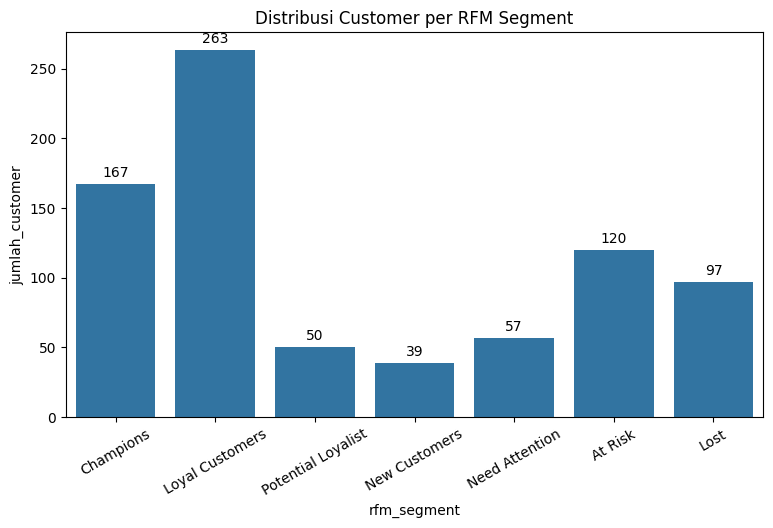

In [ ]:
# Distribusi Customer per RFM Segment
seg_dist = customer_level.groupby(['segment_order','rfm_segment']).size().reset_index(name='jumlah_customer')
seg_dist = seg_dist.sort_values('segment_order')

plt.figure(figsize=(9,5))

ax = sns.barplot(data=seg_dist, x='rfm_segment', y='jumlah_customer', order=seg_dist['rfm_segment'])

ax.bar_label(ax.containers[0], padding=3, fontsize=10)


plt.title('Distribusi Customer per RFM Segment')
plt.xticks(rotation=30)
plt.show()

In [ ]:
# Hitung CLV
# Filter Data Transaksi (Tahun 1–3 vs Tahun 4)

min_date = df['order_date'].min()
cutoff_date = min_date + pd.DateOffset(years=3)

# Filter dataset transaksi
df_cal = df[df['order_date'] <= cutoff_date]  # Data 3 Tahun Pertama (Calibration)
df_hold = df[df['order_date'] > cutoff_date]   # Data 1 Tahun Terakhir (Holdout)

In [ ]:
# Agregasi level customer dari transaksi 3 tahun pertama
cal_customers = df_cal.groupby(['customer_id', 'customer_name']).agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    total_orders=('order_id', 'nunique')
).reset_index()

# Hitung Rumus Proyeksi
cal_customers['AOV'] = cal_customers['total_sales'] / cal_customers['total_orders']
cal_customers['orders_per_yr'] = cal_customers['total_orders'] / 3.0
cal_customers['annual_revenue'] = cal_customers['AOV'] * cal_customers['orders_per_yr']

# Profit margin ratio per customer
cal_customers['margin_pct'] = cal_customers['total_profit'] / cal_customers['total_sales']

# Proyeksi Margin / Profit untuk Tahun ke-4
cal_customers['projected_margin_yr4'] = cal_customers['annual_revenue'] * cal_customers['margin_pct']

# Profit asli yang dihasilkan customer di Tahun ke-4
actual_yr4 = df_hold.groupby('customer_id')['profit'].sum().reset_index(name='actual_profit_yr4')

# Gabungkan tabel proyeksi dengan profit riil
eval_df = pd.merge(cal_customers, actual_yr4, on='customer_id', how='left').fillna({'actual_profit_yr4': 0})

# Hitung Selisih (Error) & MAE
eval_df['abs_error'] = (eval_df['projected_margin_yr4'] - eval_df['actual_profit_yr4']).abs()

mae = eval_df['abs_error'].mean()
print(f"=== HASIL VALIDASI MODEL ===")
print(f"Rata-rata Error Proyeksi per Customer : Rp {mae:,.2f}")
print(f"Total Proyeksi Profit Tahun 4              : Rp {eval_df['projected_margin_yr4'].sum():,.2f}")
print(f"Total Profit Aktual Tahun 4               : Rp {eval_df['actual_profit_yr4'].sum():,.2f}")

=== HASIL VALIDASI MODEL ===
Rata-rata Error Proyeksi per Customer : Rp 266.10
Total Proyeksi Profit Tahun 4              : Rp 64,424.52
Total Profit Aktual Tahun 4               : Rp 91,317.28


In [ ]:
df_cal_first_order = df_cal.groupby('customer_id')['order_date'].min().reset_index().rename(columns={'order_date': 'first_order_date'})
df_cal_first_order['first_year'] = df_cal_first_order['first_order_date'].dt.year
df_cal_first_order = df_cal_first_order[['customer_id', 'first_year']]

# 1. Isolasi Transaksi yang Terjadi di Tahun Pertama Pelanggan Bergabung
df_cal_merged = df_cal.merge(df_cal_first_order, on='customer_id')
df_cal_merged['order_year'] = df_cal_merged['order_date'].dt.year

# Filter transaksi pelanggan HANYA pada tahun pertama mereka (order_year == first_year)
new_cust_first_year_trans = df_cal_merged[df_cal_merged['order_year'] == df_cal_merged['first_year']]

# 2. Hitung Rata-Rata Profit dari Akuisisi Pelanggan Baru per Tahun
new_cust_profit_avg = new_cust_first_year_trans.groupby('first_year')['profit'].sum().mean()

# Define existing_proj before use
existing_proj = eval_df['projected_margin_yr4'].sum()

# 3. Total Proyeksi Gabungan (Existing + New Customers)
total_projected_yr4 = existing_proj + new_cust_profit_avg

print("=== HASIL REVISI AKURAT ===")
print(f"Proyeksi Existing Customer : Rp {existing_proj:,.2f}")
print(f"Estimasi New Customer Rate  : Rp {new_cust_profit_avg:,.2f}")
print(f"Total Proyeksi Disesuaikan  : Rp {total_projected_yr4:,.2f}")
print(f"Total Profit Aktual Tahun 4 : Rp {eval_df['actual_profit_yr4'].sum():,.2f}")

=== HASIL REVISI AKURAT ===
Proyeksi Existing Customer : Rp 64,424.52
Estimasi New Customer Rate  : Rp 23,904.56
Total Proyeksi Disesuaikan  : Rp 88,329.08
Total Profit Aktual Tahun 4 : Rp 91,317.28


In [ ]:
# 1. Proyeksi Existing Customer untuk Tahun ke-5 (Menggunakan data penuh Tahun 1-4)
full_customers = df.groupby(['customer_id', 'customer_name']).agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    total_orders=('order_id', 'nunique')
).reset_index()

# Hitung AOV, frekuensi order tahunan (dibagi 4 tahun), dan persentase margin
full_customers['AOV'] = full_customers['total_sales'] / full_customers['total_orders']
full_customers['orders_per_yr'] = full_customers['total_orders'] / 4.0
full_customers['annual_revenue'] = full_customers['AOV'] * full_customers['orders_per_yr']
full_customers['margin_pct'] = full_customers['total_profit'] / full_customers['total_sales']

# Hitung proyeksi profit 1 tahun ke depan per customer
full_customers['projected_margin_yr5'] = full_customers['annual_revenue'] * full_customers['margin_pct']
existing_proj_yr5 = full_customers['projected_margin_yr5'].sum()

# 2. Total Proyeksi Gabungan Tahun ke-5 (Existing + Rate New Customer)
total_projected_yr5 = existing_proj_yr5 + new_cust_profit_avg

print("=== PROYEKSI RESMI TAHUN KE-5 ===")
print(f"Proyeksi Existing Customer : Rp {existing_proj_yr5:,.2f}")
print(f"Estimasi New Customer Rate  : Rp {new_cust_profit_avg:,.2f}")
print(f"--------------------------------------------------")
print(f"TOTAL PROYEKSI PROFIT THN 5 : Rp {total_projected_yr5:,.2f}")

=== PROYEKSI RESMI TAHUN KE-5 ===
Proyeksi Existing Customer : Rp 71,599.26
Estimasi New Customer Rate  : Rp 23,904.56
--------------------------------------------------
TOTAL PROYEKSI PROFIT THN 5 : Rp 95,503.81


In [ ]:
full_customers['clv_score'] = pd.qcut(
    full_customers['projected_margin_yr5'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# 2. Mapping Angka Score ke Nama Segmen
clv_segment_map = {
    5: 'Premium',
    4: 'High Value',
    3: 'Mid Value',
    2: 'Low Value',
    1: 'Minimal Value'
}

full_customers['clv_segment'] = full_customers['clv_score'].map(clv_segment_map)
output_count = full_customers['clv_segment'].value_counts().reindex(clv_segment_map.values())
output_count

,count
clv_segment,
Premium,159
High Value,158
Mid Value,159
Low Value,158
Minimal Value,159


In [ ]:
# 1. Segmen Berdasarkan Historis (Tahun 1-4)
full_customers['clv_score_historis'] = pd.qcut(
    full_customers['total_profit'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

full_customers['clv_segment_historis'] = full_customers['clv_score_historis'].map(clv_segment_map)

# 2. Segmen Berdasarkan Proyeksi (Tahun ke-5)
full_customers['clv_score_projected'] = pd.qcut(
    full_customers['projected_margin_yr5'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

full_customers['clv_segment_projected'] = full_customers['clv_score_projected'].map(clv_segment_map)
full_customers.head()

,customer_id,customer_name,total_sales,total_profit,total_orders,AOV,orders_per_yr,annual_revenue,margin_pct,projected_margin_yr5,clv_score,clv_segment,clv_score_historis,clv_segment_historis,clv_score_projected,clv_segment_projected
0,AA-10315,Alex Avila,5563.56,-362.88,5,1112.71,1.25,1390.89,-0.07,-90.72,1,Minimal Value,1,Minimal Value,1,Minimal Value
1,AA-10375,Allen Armold,1056.39,277.38,9,117.38,2.25,264.10,0.26,69.35,3,Mid Value,3,Mid Value,3,Mid Value
2,AA-10480,Andrew Allen,1790.51,435.83,4,447.63,1.00,447.63,0.24,108.96,4,High Value,4,High Value,4,High Value
3,AA-10645,Anna Andreadi,5086.93,857.80,6,847.82,1.50,1271.73,0.17,214.45,5,Premium,5,Premium,5,Premium
4,AB-10015,Aaron Bergman,886.16,129.35,3,295.39,0.75,221.54,0.15,32.34,2,Low Value,2,Low Value,2,Low Value


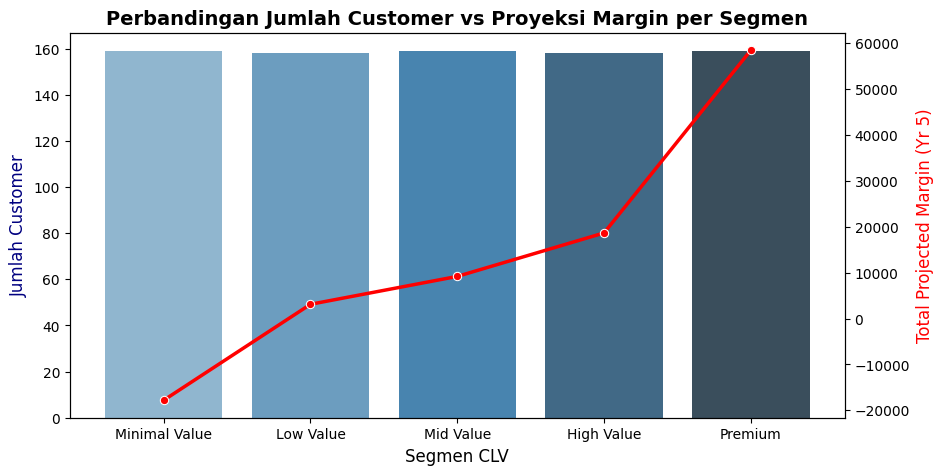

In [ ]:
# Aggregasi data per segmen
segment_summary = full_customers.groupby('clv_segment', observed=False).agg(
    total_customers=('customer_id', 'count'),
    total_projected_profit=('projected_margin_yr5', 'sum')
).reindex(['Minimal Value', 'Low Value', 'Mid Value', 'High Value', 'Premium'])

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart untuk jumlah customer
# Kode Baru (tanpa warning)
sns.barplot(
    x=segment_summary.index,
    y=segment_summary['total_customers'],
    hue=segment_summary.index,
    ax=ax1,
    palette='Blues_d',
    legend=False
)
ax1.set_ylabel('Jumlah Customer', color='navy', fontsize=12)
ax1.set_xlabel('Segmen CLV', fontsize=12)

# Line chart overlay untuk total profit
ax2 = ax1.twinx()
sns.lineplot(x=segment_summary.index, y=segment_summary['total_projected_profit'], ax=ax2, color='red', marker='o', linewidth=2.5)
ax2.set_ylabel('Total Projected Margin (Yr 5)', color='red', fontsize=12)

plt.title('Perbandingan Jumlah Customer vs Proyeksi Margin per Segmen', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
import pandas as pd

# 1. Tentukan urutan label untuk baris (RFM) dan kolom (CLV)
rfm_order = [
    'Champions',
    'Loyal Customers',
    'Potential Loyalist',
    'New Customers',
    'Need Attention',
    'At Risk',
    'Lost'
]

clv_order = ['Premium', 'High Value', 'Mid Value', 'Low Value', 'Minimal Value']

# Merge rfm_segment from customer_level into full_customers
full_customers = full_customers.merge(customer_level[['customer_id', 'rfm_segment']], on='customer_id', how='left')

# 2. Buat tabel silang (crosstab)
cross = pd.crosstab(
    full_customers['rfm_segment'],
    full_customers['clv_segment']
)

# 3. Urutkan baris dan kolom agar rapi sesuai hierarki
cross = cross.reindex(index=rfm_order, columns=clv_order).fillna(0).astype(int)

# Tampilkan hasil
cross

clv_segment,Premium,High Value,Mid Value,Low Value,Minimal Value
rfm_segment,,,,,
Champions,52,40,35,18,22
Loyal Customers,61,66,48,40,48
Potential Loyalist,6,9,12,13,10
New Customers,5,3,10,14,7
Need Attention,7,9,10,19,12
At Risk,23,22,25,23,27
Lost,5,9,19,31,33


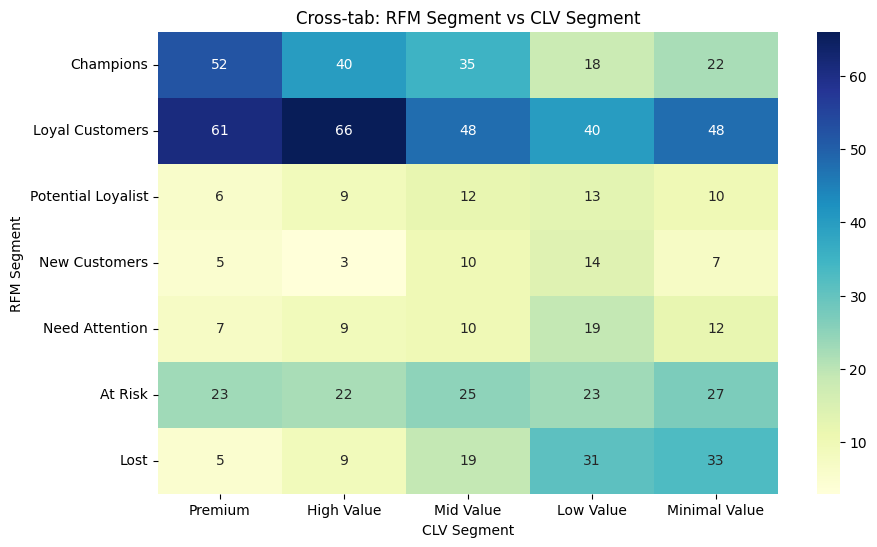

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(cross, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Cross-tab: RFM Segment vs CLV Segment')
plt.ylabel('RFM Segment')
plt.xlabel('CLV Segment')
plt.show()